# Statistical Analysis

In [27]:
# ============================================================
# 06_02_time_series_baselines.ipynb
# Load + Prepare 80072ned_silver
# ============================================================

# ------------------------------------------------------------
# Imports
# ------------------------------------------------------------

import numpy as np
import pandas as pd

from src.config import DIR_DB_SILVER
from src.utils.m_query_database import f_query_database
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX


# ============================================================
# LOAD SILVER DATA
# ============================================================

query = 'SELECT * FROM "80072ned_silver"'

df = f_query_database(
    db_path=DIR_DB_SILVER,
    query=query,
    return_type="pandas"
)


# ============================================================
# TARGET CLEANING
# ============================================================

TARGET_COL = "Ziekteverzuimpercentage_1"

df[TARGET_COL] = pd.to_numeric(
    df[TARGET_COL],
    errors="coerce"
)


# ============================================================
# CBS PERIODEN → TEMPORAL FEATURES
# ============================================================

# ------------------------------------------------------------
# Determine observation frequency
# ------------------------------------------------------------

df["frequency"] = np.select(
    [
        df["Perioden"].str.contains("KW", na=False),
        df["Perioden"].str.contains("MM", na=False),
        df["Perioden"].str.contains("JJ", na=False),
    ],
    [
        "quarterly",
        "monthly",
        "annual",
    ],
    default="unknown"
)


# ------------------------------------------------------------
# Extract year
# ------------------------------------------------------------

df["year"] = pd.to_numeric(
    df["Perioden"].str[:4],
    errors="coerce"
)


# ------------------------------------------------------------
# Extract quarter
# Example:
# 2024KW01 -> 1
# ------------------------------------------------------------

df["quarter"] = (
    df["Perioden"]
    .str.extract(r"KW(\d{2})")[0]
)

df["quarter"] = pd.to_numeric(
    df["quarter"],
    errors="coerce"
)


# ------------------------------------------------------------
# Create period_enddate
# ------------------------------------------------------------

df["period_enddate"] = pd.NaT


# Quarterly dates
mask_q = df["frequency"] == "quarterly"

df.loc[mask_q, "period_enddate"] = (
    pd.PeriodIndex.from_fields(
        year=df.loc[mask_q, "year"].astype(int),
        quarter=df.loc[mask_q, "quarter"].astype(int),
        freq="Q"
    )
    .to_timestamp(how="end")
)


# Annual dates
mask_y = df["frequency"] == "annual"

df.loc[mask_y, "period_enddate"] = pd.to_datetime(
    df.loc[mask_y, "year"].astype(int).astype(str) + "-12-31"
)


# Clean timestamp precision
df["period_enddate"] = (
    pd.to_datetime(df["period_enddate"])
    .dt.normalize()
)


# Final nullable integer cleanup
df["year"] = df["year"].astype("Int64")
df["quarter"] = df["quarter"].astype("Int64")


# ============================================================
# KEEP ONLY QUARTERLY OBSERVATIONS
# ============================================================

df = (
    df[df["frequency"] == "quarterly"]
    .copy()
)


# ============================================================
# CREATE TOTAL ECONOMY SERIES
# T001081 = Total Economy
# ============================================================

df_total = (
    df[
        df["BedrijfskenmerkenSBI2008"] == "T001081"
    ]
    .copy()
)


# ============================================================
# FINAL MODELING DATAFRAME
# ============================================================

df_total = (
    df_total
    .sort_values("period_enddate")
    .reset_index(drop=True)
)

df_total = df_total[
    [
        "period_enddate",
        "year",
        "quarter",
        "frequency",
        TARGET_COL,
    ]
].copy()


# ============================================================
# VALIDATION
# ============================================================

print("Shape:", df_total.shape)

print("\nDate Range:")
print(df_total["period_enddate"].min())
print(df_total["period_enddate"].max())

print("\nMissing Target Values:")
print(df_total[TARGET_COL].isna().sum())

display(df_total.head())

✅ Query returned 5850 rows from silver_data.db as pandas DataFrame


Shape: (120, 5)

Date Range:
1996-03-31 00:00:00
2025-12-31 00:00:00

Missing Target Values:
0


,period_enddate,year,quarter,frequency,Ziekteverzuimpercentage_1
0,1996-03-31,1996,1,quarterly,5.5
1,1996-06-30,1996,2,quarterly,4.6
2,1996-09-30,1996,3,quarterly,4.0
3,1996-12-31,1996,4,quarterly,4.7
4,1997-03-31,1997,1,quarterly,4.9


period_enddate
1996-03-31    5.5
1996-06-30    4.6
1996-09-30    4.0
1996-12-31    4.7
1997-03-31    4.9
Freq: QE-DEC, Name: Ziekteverzuimpercentage_1, dtype: float64
<QuarterEnd: startingMonth=12>


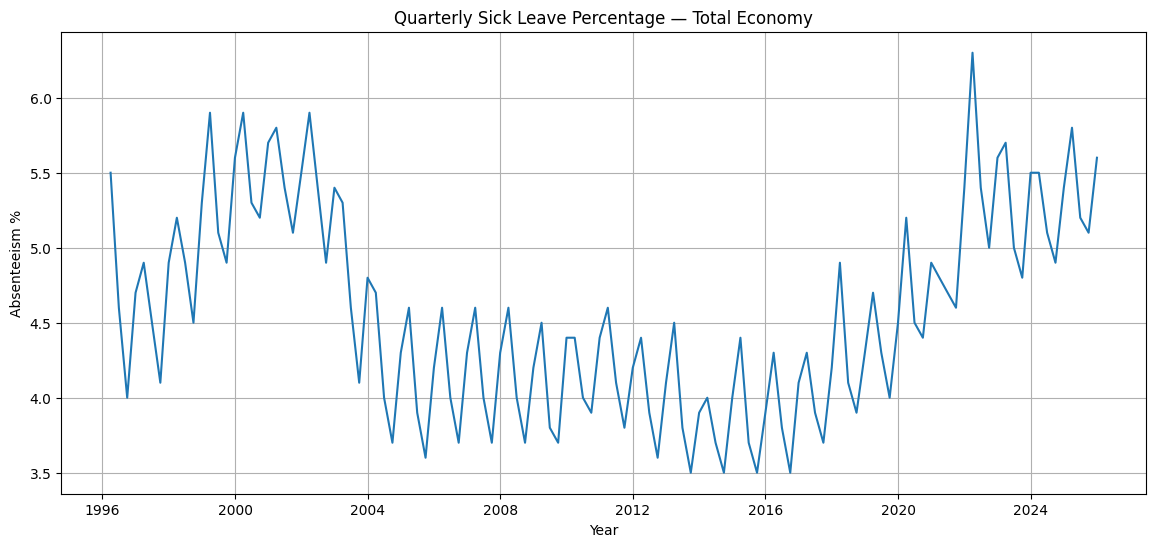

In [4]:
# ============================================================
# CREATE TIME SERIES
# ============================================================

df_ts = (
    df_total
    .set_index("period_enddate")
    ["Ziekteverzuimpercentage_1"]
    .copy()
)

df_ts = df_ts.asfreq("QE")


print(df_ts.head())
print(df_ts.index.freq)

# ============================================================
# PLOT TOTAL ECONOMY ABSENTEEISM
# ============================================================

import matplotlib.pyplot as plt


plt.figure(figsize=(14, 6))

plt.plot(
    df_ts.index,
    df_ts.values,
)

plt.title("Quarterly Sick Leave Percentage — Total Economy")
plt.xlabel("Year")
plt.ylabel("Absenteeism %")

plt.grid(True)

plt.show()

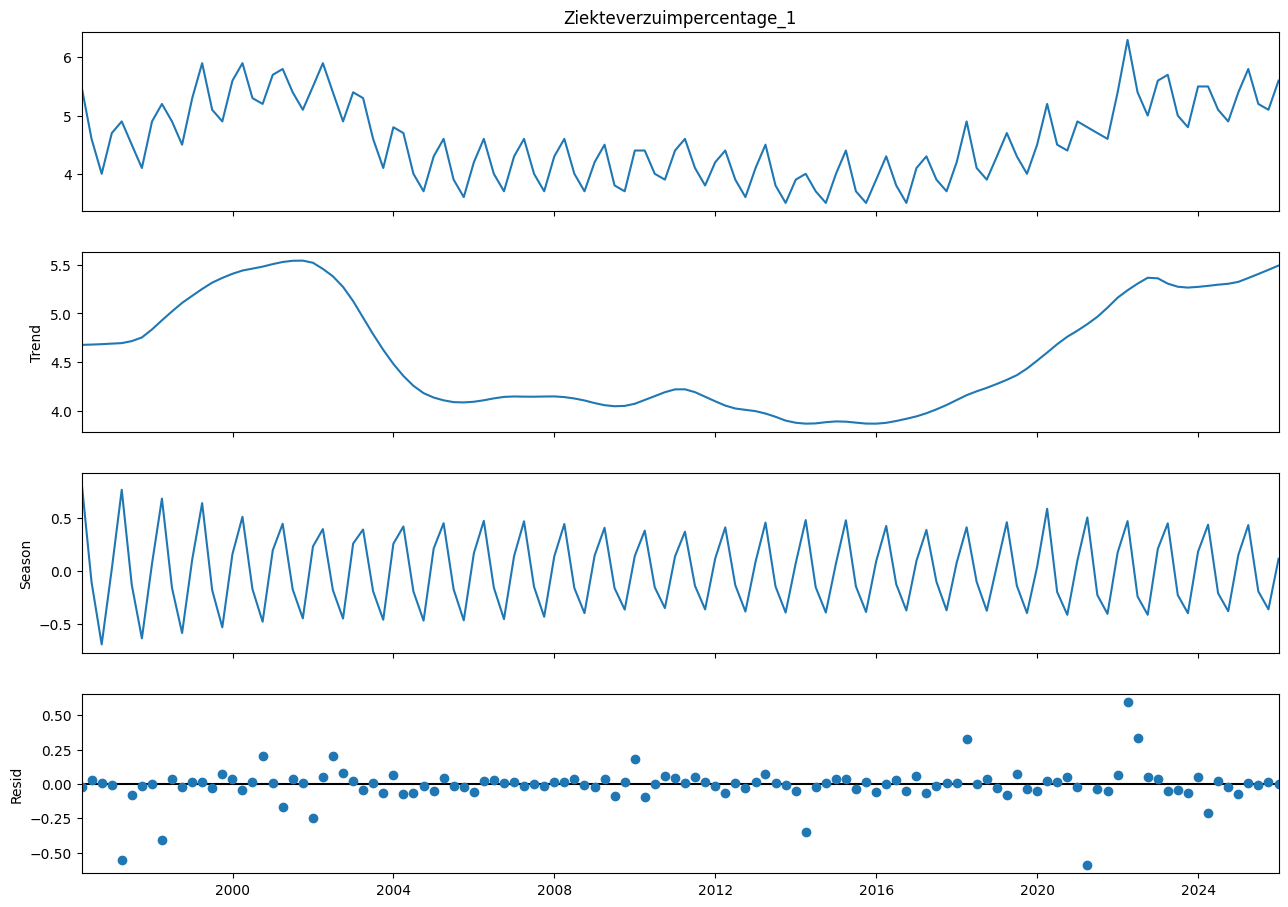

In [5]:
# ============================================================
# STL DECOMPOSITION
# ============================================================




stl = STL(
    df_ts,
    period=4,   # quarterly seasonality
    robust=True
)

result = stl.fit()


fig = result.plot()

fig.set_size_inches(14, 10)

plt.show()

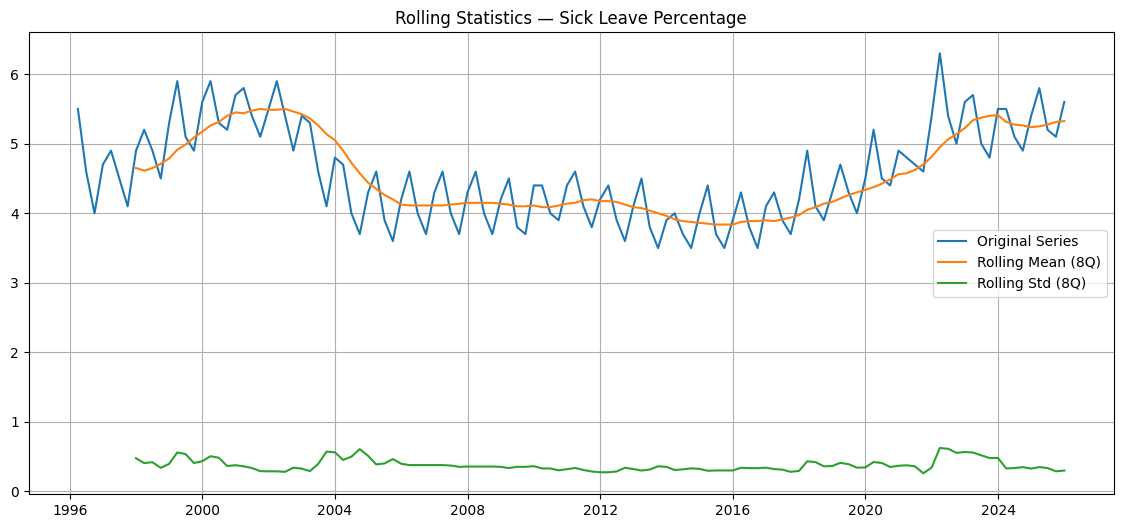

In [6]:
# ============================================================
# ROLLING MEAN & STD
# ============================================================

rolling_mean = df_ts.rolling(window=8).mean()
rolling_std = df_ts.rolling(window=8).std()


plt.figure(figsize=(14, 6))

plt.plot(df_ts, label="Original Series")
plt.plot(rolling_mean, label="Rolling Mean (8Q)")
plt.plot(rolling_std, label="Rolling Std (8Q)")

plt.title("Rolling Statistics — Sick Leave Percentage")

plt.legend()

plt.grid(True)

plt.show()

In [8]:
# ============================================================
# AUGMENTED DICKEY-FULLER TEST
# ============================================================



adf_result = adfuller(df_ts)


print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

print("\nCritical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value:.4f}")

ADF Statistic: -1.9332414525252926
p-value: 0.3165884386370146

Critical Values:
1%: -3.4930
5%: -2.8890
10%: -2.5814


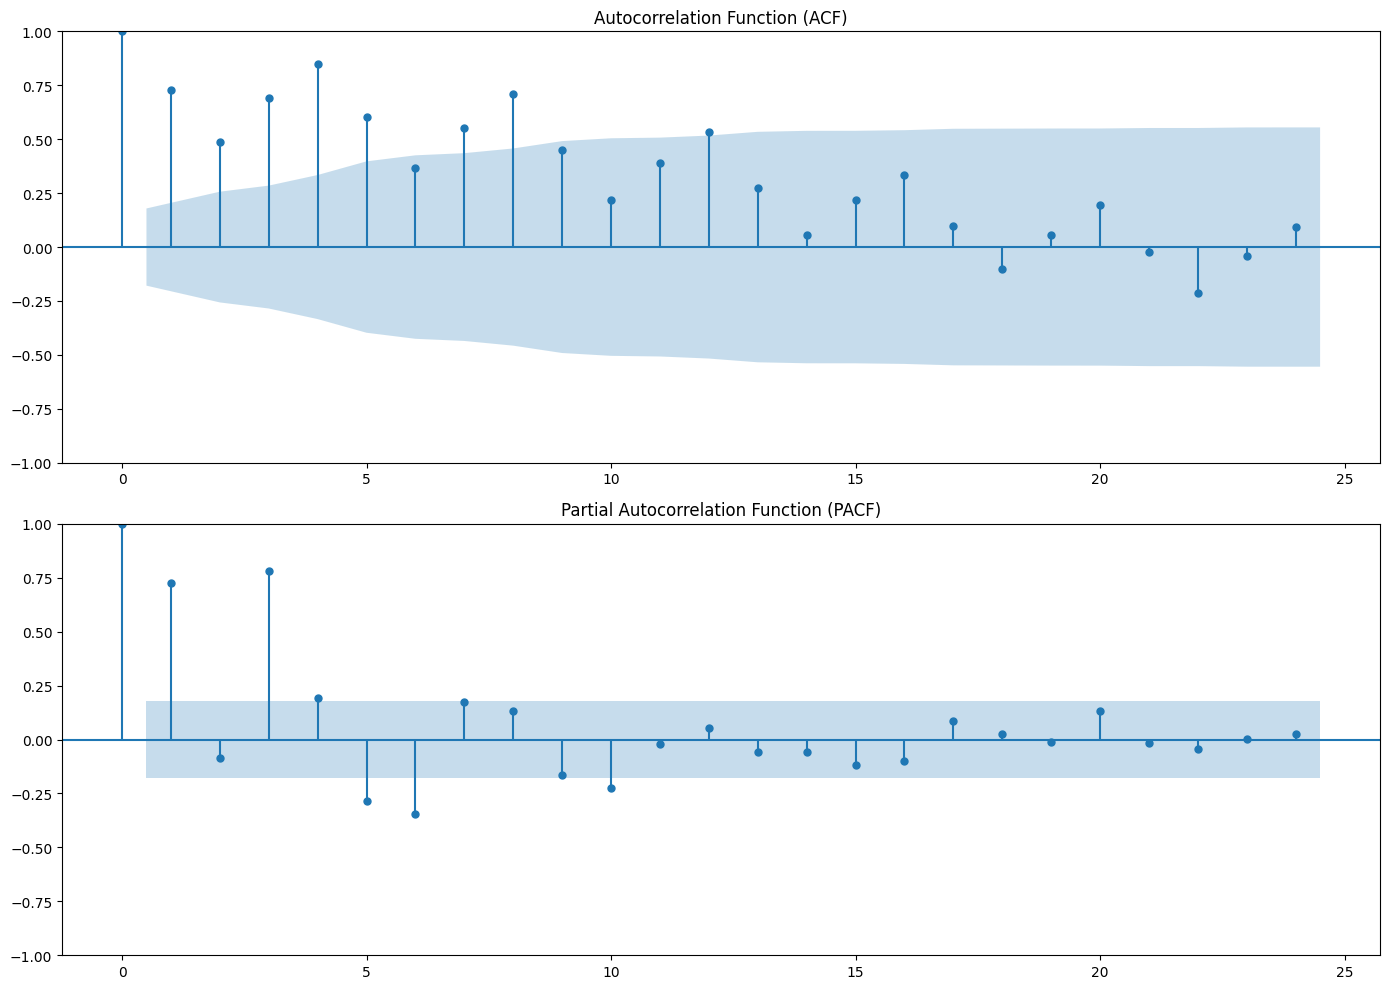

In [10]:
# ============================================================
# ACF & PACF
# ============================================================



fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 10)
)

plot_acf(
    df_ts,
    lags=24,
    ax=axes[0]
)

plot_pacf(
    df_ts,
    lags=24,
    ax=axes[1],
    method="ywm"
)

axes[0].set_title("Autocorrelation Function (ACF)")
axes[1].set_title("Partial Autocorrelation Function (PACF)")

plt.tight_layout()

plt.show()

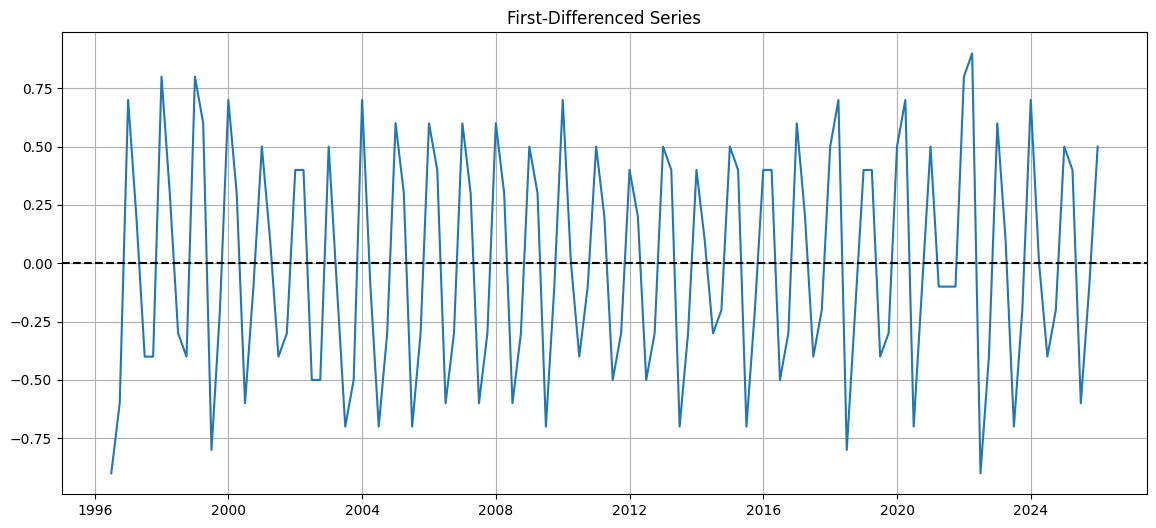

ADF Statistic: -3.234980660638842
p-value: 0.018047074339215992

Critical Values:
1%: -3.4924
5%: -2.8887
10%: -2.5813


In [12]:
# ============================================================
# FIRST DIFFERENCING
# ============================================================

df_diff_1 = df_ts.diff()


plt.figure(figsize=(14, 6))

plt.plot(df_diff_1)

plt.title("First-Differenced Series")

plt.axhline(
    y=0,
    color="black",
    linestyle="--"
)

plt.grid(True)

plt.show()

# ============================================================
# ADF TEST — FIRST DIFFERENCE
# ============================================================

adf_diff_1 = adfuller(
    df_diff_1.dropna()
)

print("ADF Statistic:", adf_diff_1[0])
print("p-value:", adf_diff_1[1])

print("\nCritical Values:")

for key, value in adf_diff_1[4].items():
    print(f"{key}: {value:.4f}")

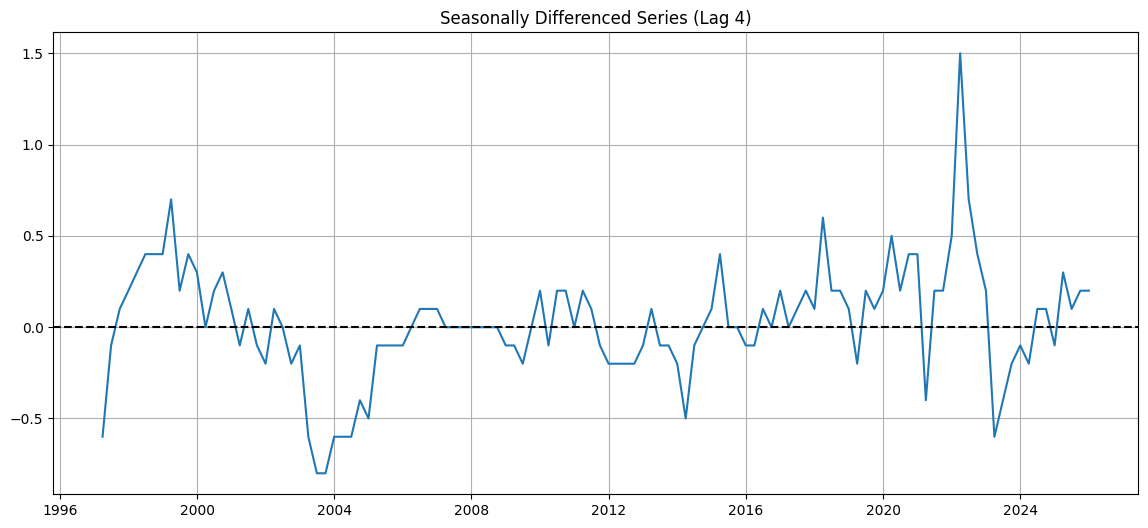

ADF Statistic: -2.687628425388089
p-value: 0.0762036675629172

Critical Values:
1%: -3.4930
5%: -2.8890
10%: -2.5814


In [13]:
# ============================================================
# SEASONAL DIFFERENCING (lag = 4 quarters)
# ============================================================

df_diff_seasonal = df_ts.diff(4)


plt.figure(figsize=(14, 6))

plt.plot(df_diff_seasonal)

plt.title("Seasonally Differenced Series (Lag 4)")

plt.axhline(
    y=0,
    color="black",
    linestyle="--"
)

plt.grid(True)

plt.show()

# ============================================================
# ADF TEST — SEASONAL DIFFERENCE
# ============================================================

adf_seasonal = adfuller(
    df_diff_seasonal.dropna()
)

print("ADF Statistic:", adf_seasonal[0])
print("p-value:", adf_seasonal[1])

print("\nCritical Values:")

for key, value in adf_seasonal[4].items():
    print(f"{key}: {value:.4f}")

## Statistical Summary Analysis

- The absenteeism series exhibits strong and stable quarterly seasonality.
- Significant structural level shifts occur post-2020.
- The raw series is nonstationary according to the ADF test.
- First differencing substantially improves stationarity.
- Seasonal differencing appears less effective, suggesting that the primary nonstationarity originates from trend/level changes rather than unstable seasonality.
- Residual shocks around COVID indicate possible external structural drivers not captured by historical dynamics alone.

# TimeSeries Modeling

In [18]:
# ============================================================
# FORECAST EVALUATION UTILITIES
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)


def calculate_metrics(y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    mape = (
        (
            (y_true - y_pred).abs() / y_true
        ).mean()
    ) * 100

    return {
    "MAE": float(mae),
    "RMSE": float(rmse),
    "MAPE": float(mape),
}

# ============================================================
# WALK-FORWARD SETTINGS
# ============================================================

FORECAST_HORIZON = 4

INITIAL_TRAIN_SIZE = 80

In [19]:
# ============================================================
# SEASONAL NAIVE FORECAST
# ============================================================

import pandas as pd


all_forecasts = []
all_actuals = []
all_dates = []


# ------------------------------------------------------------
# Walk-forward forecasting
# ------------------------------------------------------------

for i in range(
    INITIAL_TRAIN_SIZE,
    len(df_ts) - FORECAST_HORIZON + 1
):

    # --------------------------------------------------------
    # Train series
    # --------------------------------------------------------

    train = df_ts.iloc[:i]

    # --------------------------------------------------------
    # Test window
    # --------------------------------------------------------

    test = df_ts.iloc[i:i + FORECAST_HORIZON]

    # --------------------------------------------------------
    # Seasonal naive forecast
    # Forecast = same quarter previous year
    # --------------------------------------------------------

    forecast = train.iloc[-4:].values

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    all_forecasts.extend(forecast)

    all_actuals.extend(test.values)

    all_dates.extend(test.index)


# ============================================================
# RESULTS DATAFRAME
# ============================================================

results_sn = pd.DataFrame({
    "date": all_dates,
    "actual": all_actuals,
    "forecast": all_forecasts,
})

results_sn = results_sn.drop_duplicates(
    subset="date"
)

results_sn = results_sn.sort_values(
    "date"
)


# ============================================================
# EVALUATE
# ============================================================

metrics_sn = calculate_metrics(
    results_sn["actual"],
    results_sn["forecast"]
)

print(metrics_sn)


display(results_sn.head())

{'MAE': 0.27, 'RMSE': 0.372827037646145, 'MAPE': 5.376411351702102}


,date,actual,forecast
0,2016-03-31,4.3,4.4
1,2016-06-30,3.8,3.7
2,2016-09-30,3.5,3.5
3,2016-12-31,4.1,3.9
7,2017-03-31,4.3,4.3


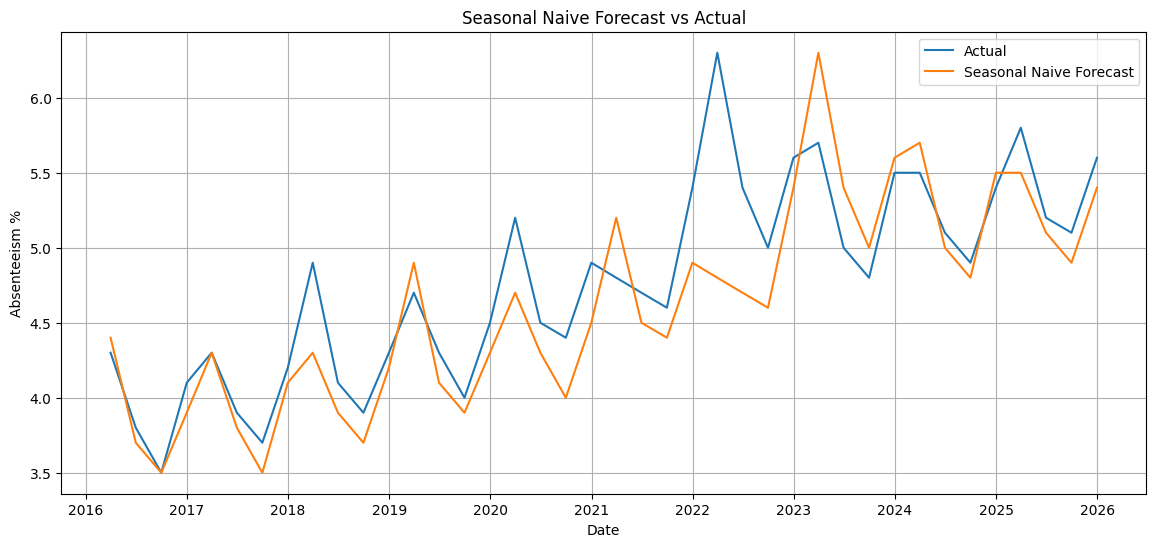

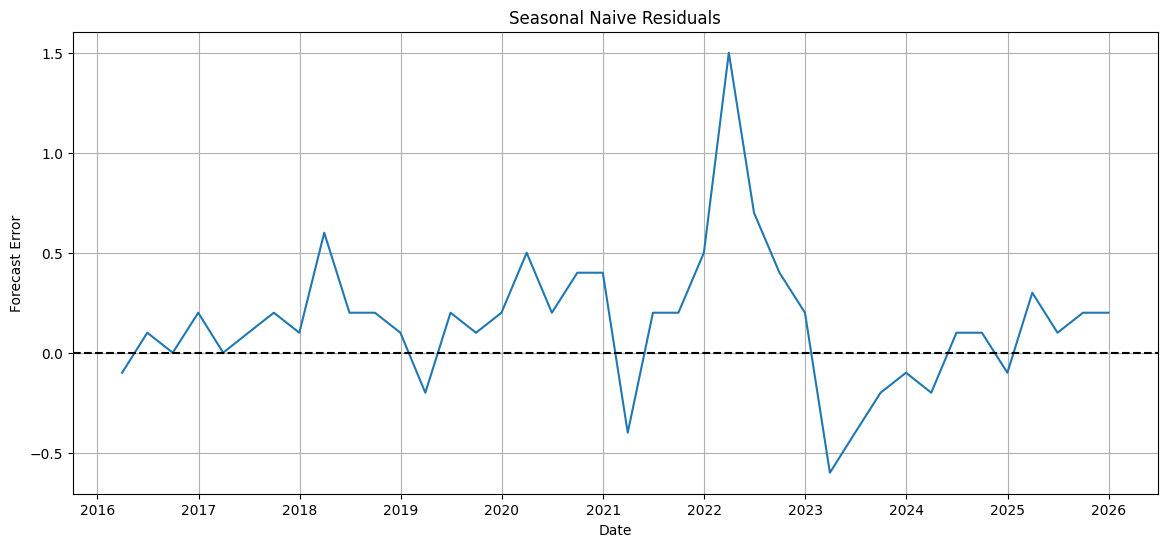

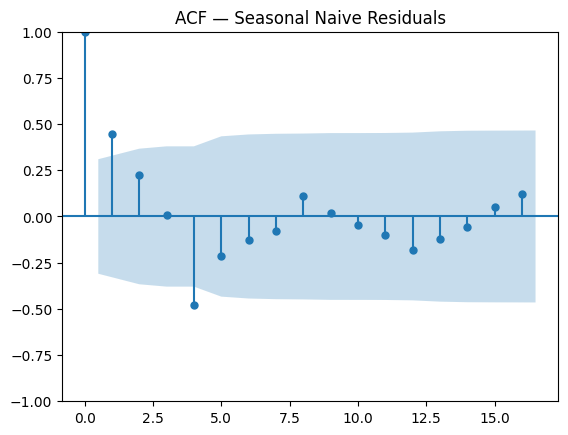

In [21]:
# ============================================================
# PLOT ACTUAL VS FORECAST
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    results_sn["date"],
    results_sn["actual"],
    label="Actual"
)

plt.plot(
    results_sn["date"],
    results_sn["forecast"],
    label="Seasonal Naive Forecast"
)

plt.title("Seasonal Naive Forecast vs Actual")

plt.xlabel("Date")
plt.ylabel("Absenteeism %")

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# FORECAST RESIDUALS
# ============================================================

results_sn["residual"] = (
    results_sn["actual"]
    - results_sn["forecast"]
)


plt.figure(figsize=(14, 6))

plt.plot(
    results_sn["date"],
    results_sn["residual"]
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--"
)

plt.title("Seasonal Naive Residuals")

plt.xlabel("Date")
plt.ylabel("Forecast Error")

plt.grid(True)

plt.show()

# ============================================================
# RESIDUAL AUTOCORRELATION
# ============================================================

plot_acf(
    results_sn["residual"],
    lags=16
)

plt.title("ACF — Seasonal Naive Residuals")

plt.show()

{'MAE': 0.28001996733488044, 'RMSE': 0.42644246519032575, 'MAPE': 5.566660973766162}


,date,actual,forecast
0,2016-03-31,4.3,4.158879
1,2016-06-30,3.8,3.578876
2,2016-09-30,3.5,3.278878
3,2016-12-31,4.1,3.848879
7,2017-03-31,4.3,4.236649


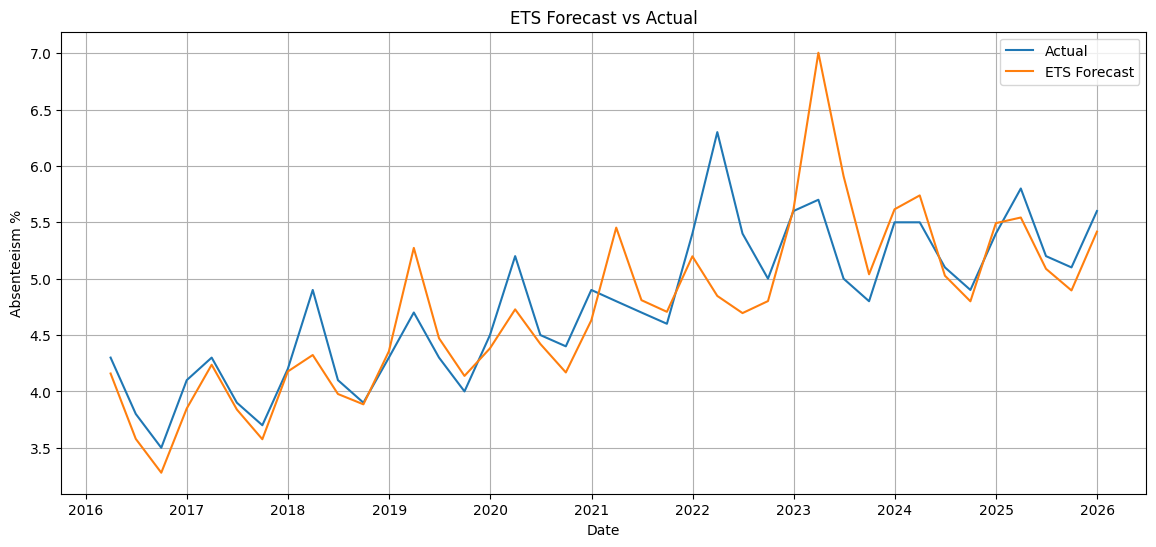

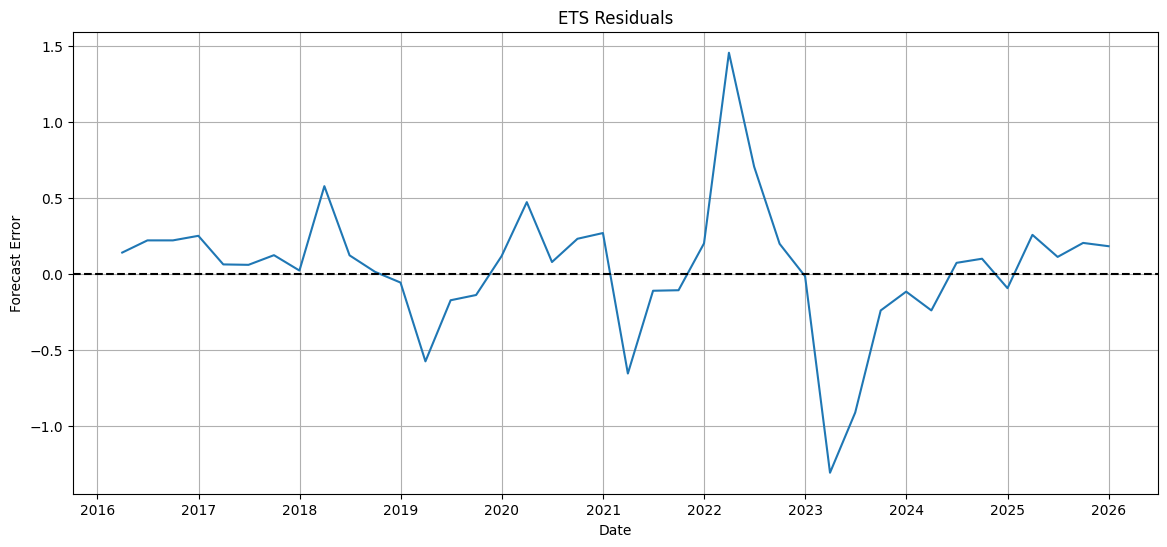

In [24]:
# ============================================================
# ETS / HOLT-WINTERS FORECAST
# ============================================================

from statsmodels.tsa.holtwinters import ExponentialSmoothing


all_forecasts_ets = []
all_actuals_ets = []
all_dates_ets = []


# ============================================================
# WALK-FORWARD FORECASTING
# ============================================================

for i in range(
    INITIAL_TRAIN_SIZE,
    len(df_ts) - FORECAST_HORIZON + 1
):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    train = df_ts.iloc[:i]

    # --------------------------------------------------------
    # TEST WINDOW
    # --------------------------------------------------------

    test = df_ts.iloc[i:i + FORECAST_HORIZON]

    # --------------------------------------------------------
    # ETS MODEL
    # --------------------------------------------------------

    model = ExponentialSmoothing(
        train,
        trend="add",
        seasonal="add",
        seasonal_periods=4
    )

    fitted_model = model.fit()

    # --------------------------------------------------------
    # FORECAST
    # --------------------------------------------------------

    forecast = fitted_model.forecast(
        FORECAST_HORIZON
    )

    # --------------------------------------------------------
    # STORE RESULTS
    # --------------------------------------------------------

    all_forecasts_ets.extend(
        forecast.values
    )

    all_actuals_ets.extend(
        test.values
    )

    all_dates_ets.extend(
        test.index
    )


# ============================================================
# RESULTS DATAFRAME
# ============================================================

results_ets = pd.DataFrame({
    "date": all_dates_ets,
    "actual": all_actuals_ets,
    "forecast": all_forecasts_ets,
})

results_ets = results_ets.drop_duplicates(
    subset="date"
)

results_ets = results_ets.sort_values(
    "date"
)


# ============================================================
# METRICS
# ============================================================

metrics_ets = calculate_metrics(
    results_ets["actual"],
    results_ets["forecast"]
)

print(metrics_ets)


display(results_ets.head())

# ============================================================
# ETS FORECAST VS ACTUAL
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    results_ets["date"],
    results_ets["actual"],
    label="Actual"
)

plt.plot(
    results_ets["date"],
    results_ets["forecast"],
    label="ETS Forecast"
)

plt.title("ETS Forecast vs Actual")

plt.xlabel("Date")
plt.ylabel("Absenteeism %")

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# ETS RESIDUALS
# ============================================================

results_ets["residual"] = (
    results_ets["actual"]
    - results_ets["forecast"]
)


plt.figure(figsize=(14, 6))

plt.plot(
    results_ets["date"],
    results_ets["residual"]
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--"
)

plt.title("ETS Residuals")

plt.xlabel("Date")
plt.ylabel("Forecast Error")

plt.grid(True)

plt.show()

{'MAE': 0.2647025614582075, 'RMSE': 0.3949583777154555, 'MAPE': 5.2229462269359805}


,date,actual,forecast
0,2016-03-31,4.3,4.377471
1,2016-06-30,3.8,3.689821
2,2016-09-30,3.5,3.484482
3,2016-12-31,4.1,3.911556
7,2017-03-31,4.3,4.266573


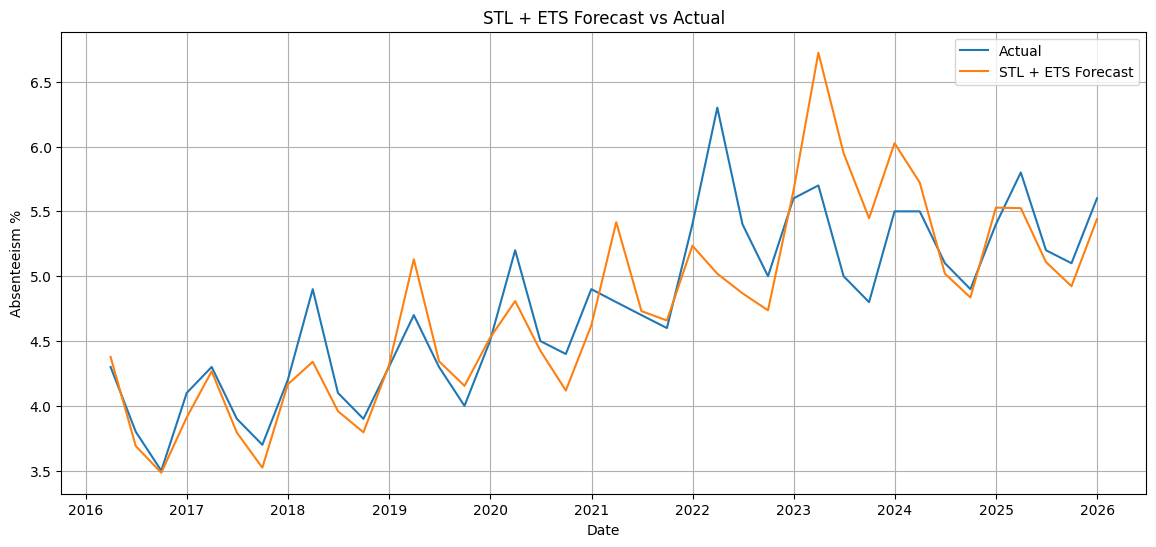

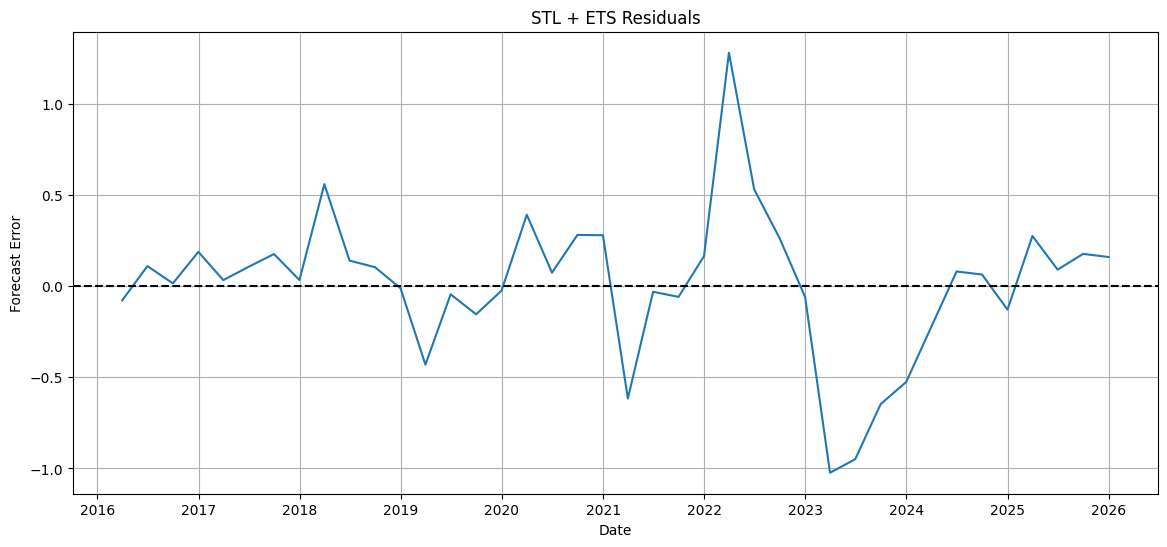

In [26]:
# ============================================================
# STL + ETS FORECAST
# ============================================================




all_forecasts_stl = []
all_actuals_stl = []
all_dates_stl = []


# ============================================================
# WALK-FORWARD FORECASTING
# ============================================================

for i in range(
    INITIAL_TRAIN_SIZE,
    len(df_ts) - FORECAST_HORIZON + 1
):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    train = df_ts.iloc[:i]

    # --------------------------------------------------------
    # TEST WINDOW
    # --------------------------------------------------------

    test = df_ts.iloc[i:i + FORECAST_HORIZON]

    # --------------------------------------------------------
    # STL DECOMPOSITION
    # --------------------------------------------------------

    stl = STL(
        train,
        period=4,
        robust=True
    )

    stl_result = stl.fit()

    # --------------------------------------------------------
    # DE-SEASONALIZED SERIES
    # --------------------------------------------------------

    deseasonalized = (
        train
        - stl_result.seasonal
    )

    # --------------------------------------------------------
    # ETS MODEL ON DE-SEASONALIZED DATA
    # --------------------------------------------------------

    model = ExponentialSmoothing(
        deseasonalized,
        trend="add",
        seasonal=None
    )

    fitted_model = model.fit()

    # --------------------------------------------------------
    # FORECAST DE-SEASONALIZED COMPONENT
    # --------------------------------------------------------

    forecast_deseasonalized = fitted_model.forecast(
        FORECAST_HORIZON
    )

    # --------------------------------------------------------
    # REPEAT LAST SEASONAL CYCLE
    # --------------------------------------------------------

    seasonal_forecast = (
        stl_result.seasonal
        .iloc[-4:]
        .values
    )

    # --------------------------------------------------------
    # FINAL FORECAST
    # --------------------------------------------------------

    forecast = (
        forecast_deseasonalized.values
        + seasonal_forecast
    )

    # --------------------------------------------------------
    # STORE RESULTS
    # --------------------------------------------------------

    all_forecasts_stl.extend(
        forecast
    )

    all_actuals_stl.extend(
        test.values
    )

    all_dates_stl.extend(
        test.index
    )


# ============================================================
# RESULTS DATAFRAME
# ============================================================

results_stl = pd.DataFrame({
    "date": all_dates_stl,
    "actual": all_actuals_stl,
    "forecast": all_forecasts_stl,
})

results_stl = results_stl.drop_duplicates(
    subset="date"
)

results_stl = results_stl.sort_values(
    "date"
)


# ============================================================
# METRICS
# ============================================================

metrics_stl = calculate_metrics(
    results_stl["actual"],
    results_stl["forecast"]
)

print(metrics_stl)

display(results_stl.head())

# ============================================================
# STL + ETS FORECAST VS ACTUAL
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    results_stl["date"],
    results_stl["actual"],
    label="Actual"
)

plt.plot(
    results_stl["date"],
    results_stl["forecast"],
    label="STL + ETS Forecast"
)

plt.title("STL + ETS Forecast vs Actual")

plt.xlabel("Date")
plt.ylabel("Absenteeism %")

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# STL + ETS RESIDUALS
# ============================================================

results_stl["residual"] = (
    results_stl["actual"]
    - results_stl["forecast"]
)


plt.figure(figsize=(14, 6))

plt.plot(
    results_stl["date"],
    results_stl["residual"]
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--"
)

plt.title("STL + ETS Residuals")

plt.xlabel("Date")
plt.ylabel("Forecast Error")

plt.grid(True)

plt.show()

{'MAE': 0.284741863078223, 'RMSE': 0.3860204833981986, 'MAPE': 5.728528569276477}


,date,actual,forecast
0,2016-03-31,4.3,4.122479
1,2016-06-30,3.8,3.633173
2,2016-09-30,3.5,3.388055
3,2016-12-31,4.1,3.860702
7,2017-03-31,4.3,4.244703


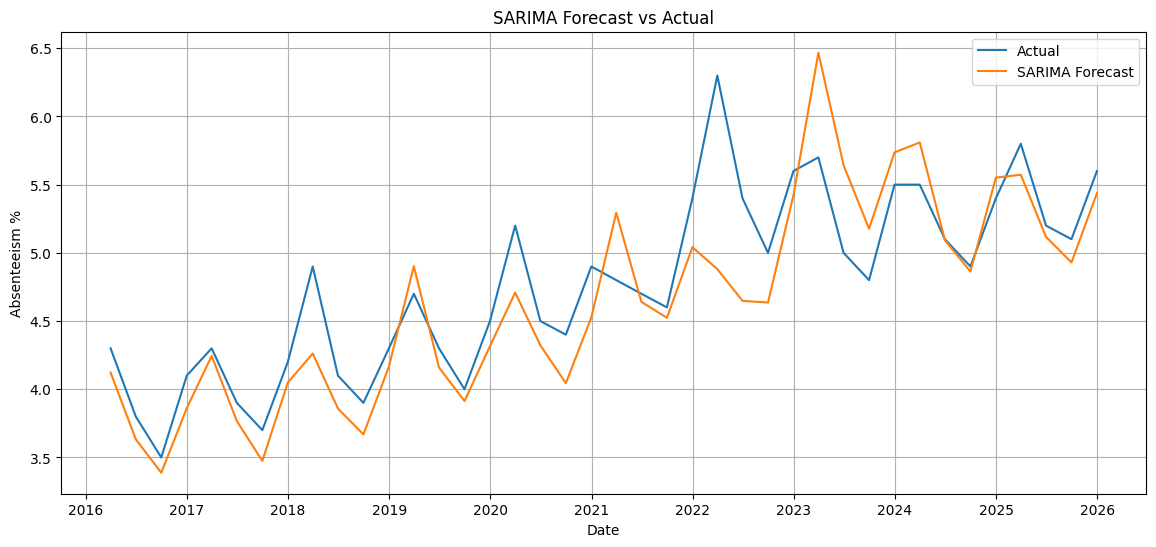

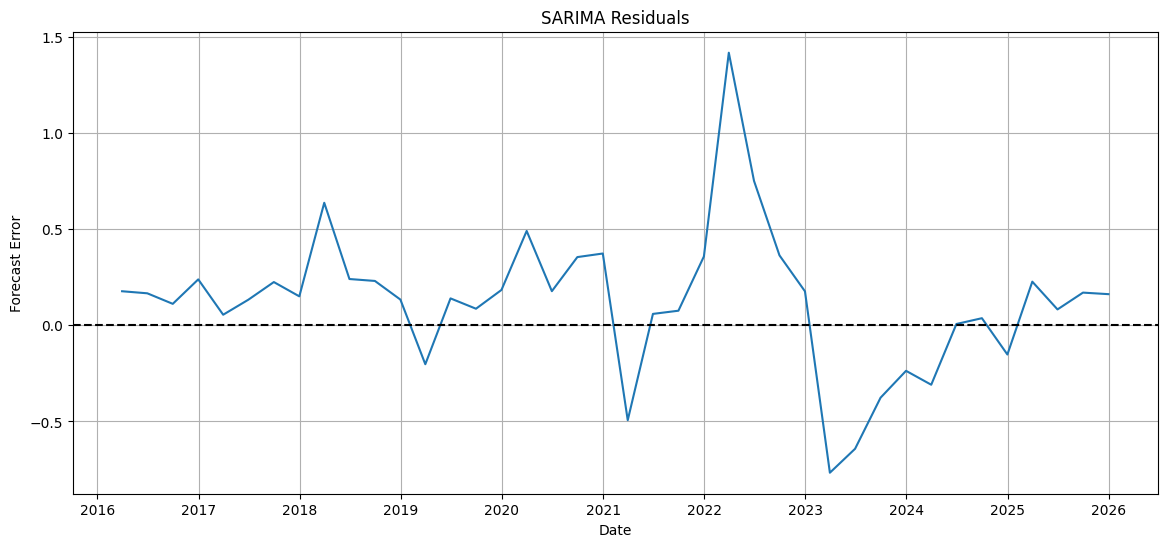

In [29]:
# ============================================================
# SARIMA FORECAST
# ============================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX


all_forecasts_sarima = []
all_actuals_sarima = []
all_dates_sarima = []


# ============================================================
# WALK-FORWARD FORECASTING
# ============================================================

for i in range(
    INITIAL_TRAIN_SIZE,
    len(df_ts) - FORECAST_HORIZON + 1
):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    train = df_ts.iloc[:i]

    # --------------------------------------------------------
    # TEST WINDOW
    # --------------------------------------------------------

    test = df_ts.iloc[i:i + FORECAST_HORIZON]

    # --------------------------------------------------------
    # SARIMA MODEL
    # --------------------------------------------------------

    model = SARIMAX(
        train,
        order=(1, 1, 1),
        seasonal_order=(1, 0, 1, 4),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted_model = model.fit(
        disp=False
    )

    # --------------------------------------------------------
    # FORECAST
    # --------------------------------------------------------

    forecast = fitted_model.forecast(
        steps=FORECAST_HORIZON
    )

    # --------------------------------------------------------
    # STORE RESULTS
    # --------------------------------------------------------

    all_forecasts_sarima.extend(
        forecast.values
    )

    all_actuals_sarima.extend(
        test.values
    )

    all_dates_sarima.extend(
        test.index
    )


# ============================================================
# RESULTS DATAFRAME
# ============================================================

results_sarima = pd.DataFrame({
    "date": all_dates_sarima,
    "actual": all_actuals_sarima,
    "forecast": all_forecasts_sarima,
})

results_sarima = results_sarima.drop_duplicates(
    subset="date"
)

results_sarima = results_sarima.sort_values(
    "date"
)


# ============================================================
# METRICS
# ============================================================

metrics_sarima = calculate_metrics(
    results_sarima["actual"],
    results_sarima["forecast"]
)

print(metrics_sarima)

display(results_sarima.head())

# ============================================================
# SARIMA FORECAST VS ACTUAL
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    results_sarima["date"],
    results_sarima["actual"],
    label="Actual"
)

plt.plot(
    results_sarima["date"],
    results_sarima["forecast"],
    label="SARIMA Forecast"
)

plt.title("SARIMA Forecast vs Actual")

plt.xlabel("Date")
plt.ylabel("Absenteeism %")

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# SARIMA RESIDUALS
# ============================================================

results_sarima["residual"] = (
    results_sarima["actual"]
    - results_sarima["forecast"]
)


plt.figure(figsize=(14, 6))

plt.plot(
    results_sarima["date"],
    results_sarima["residual"]
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--"
)

plt.title("SARIMA Residuals")

plt.xlabel("Date")
plt.ylabel("Forecast Error")

plt.grid(True)

plt.show()


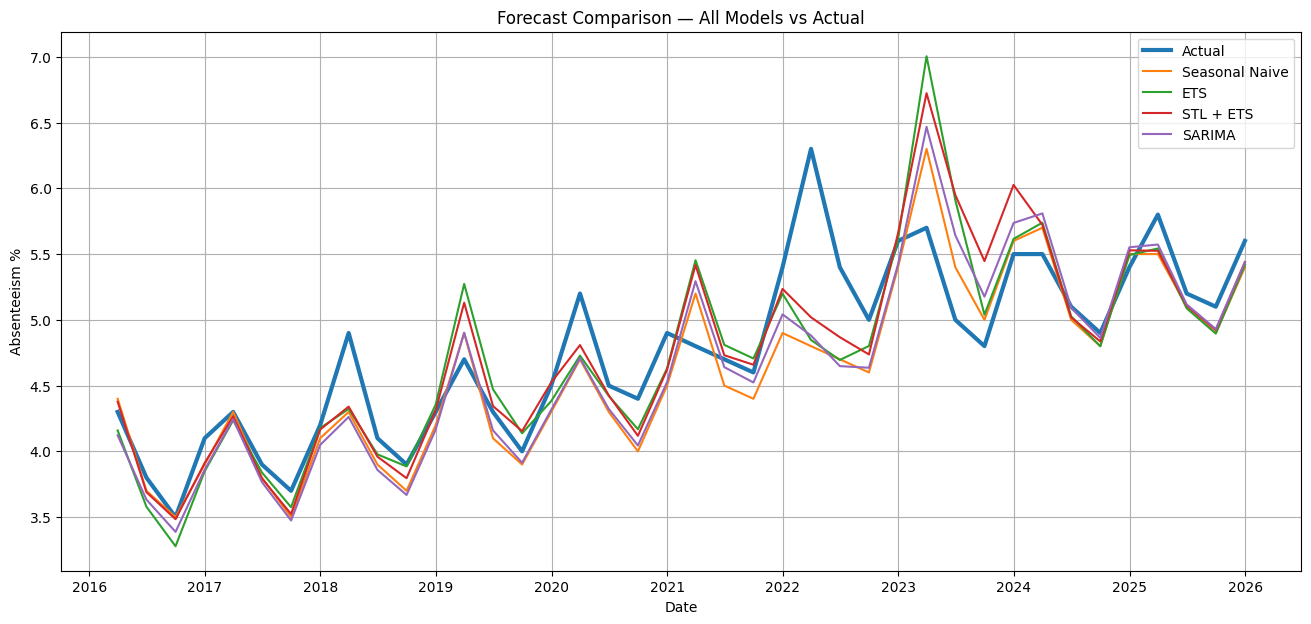

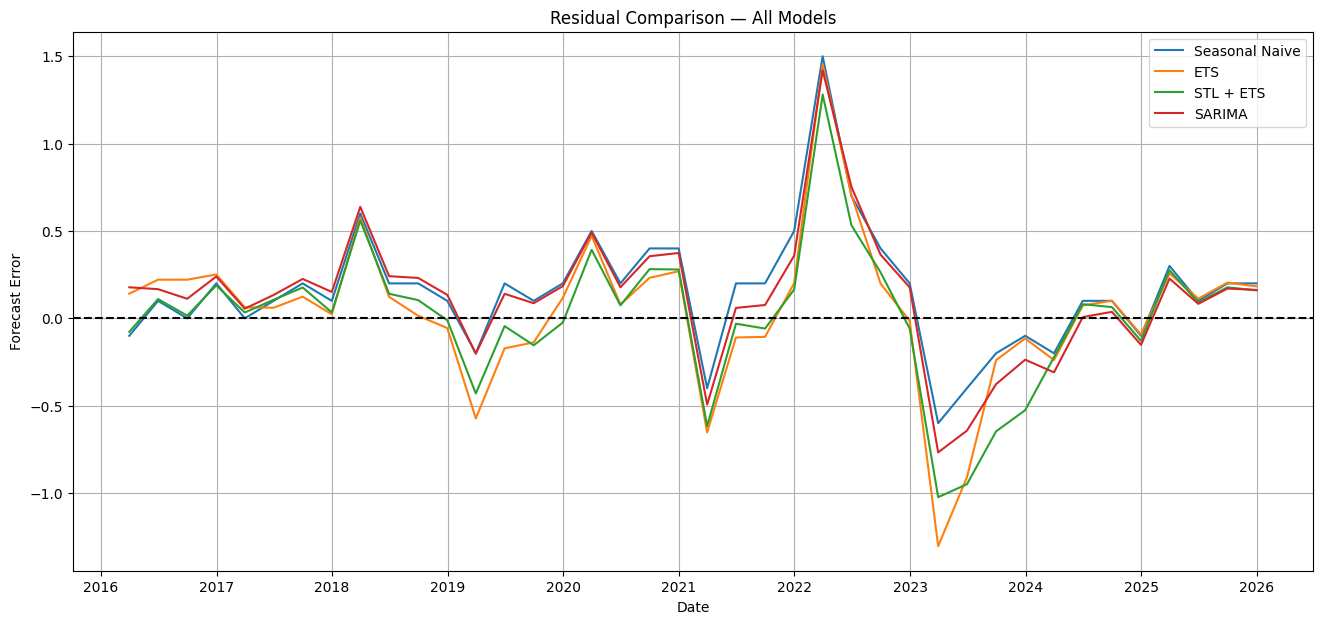

C:\Users\gebruiker\AppData\Local\Temp\ipykernel_18052\1354909983.py:175: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(


,date,Seasonal Naive,ETS,STL + ETS,SARIMA
0,2026-03-31,5.8,5.895,5.918,5.886
1,2026-06-30,5.2,5.325,5.301,5.364
2,2026-09-30,5.1,5.055,5.139,5.136
3,2026-12-31,5.6,5.622,5.621,5.658


,Model,MAE,RMSE,MAPE
0,Seasonal Naive,0.270,0.373,5.376
1,ETS,0.280,0.426,5.567
2,STL + ETS,0.265,0.395,5.223
3,SARIMA,0.285,0.386,5.729


,Model,MAE,RMSE,MAPE
0,Seasonal Naive,0.270,0.373,5.376
1,SARIMA,0.285,0.386,5.729
2,STL + ETS,0.265,0.395,5.223
3,ETS,0.280,0.426,5.567


In [33]:
# ============================================================
# MODEL COMPARISON TABLE
# ============================================================

comparison_df = pd.DataFrame([
    {
        "Model": "Seasonal Naive",
        **metrics_sn
    },
    {
        "Model": "ETS",
        **metrics_ets
    },
    {
        "Model": "STL + ETS",
        **metrics_stl
    },
    {
        "Model": "SARIMA",
        **metrics_sarima
    }
])

comparison_df = comparison_df.round(3)

comparison_df

# ============================================================
# FORECAST COMPARISON — ALL MODELS VS ACTUAL
# ============================================================

plt.figure(figsize=(16, 7))

# ------------------------------------------------------------
# ACTUAL
# ------------------------------------------------------------

plt.plot(
    results_sn["date"],
    results_sn["actual"],
    label="Actual",
    linewidth=3
)

# ------------------------------------------------------------
# SEASONAL NAIVE
# ------------------------------------------------------------

plt.plot(
    results_sn["date"],
    results_sn["forecast"],
    label="Seasonal Naive"
)

# ------------------------------------------------------------
# ETS
# ------------------------------------------------------------

plt.plot(
    results_ets["date"],
    results_ets["forecast"],
    label="ETS"
)

# ------------------------------------------------------------
# STL + ETS
# ------------------------------------------------------------

plt.plot(
    results_stl["date"],
    results_stl["forecast"],
    label="STL + ETS"
)

# ------------------------------------------------------------
# SARIMA
# ------------------------------------------------------------

plt.plot(
    results_sarima["date"],
    results_sarima["forecast"],
    label="SARIMA"
)

# ------------------------------------------------------------
# FORMATTING
# ------------------------------------------------------------

plt.title("Forecast Comparison — All Models vs Actual")

plt.xlabel("Date")
plt.ylabel("Absenteeism %")

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# RESIDUAL COMPARISON
# ============================================================

plt.figure(figsize=(16, 7))

# ------------------------------------------------------------
# SEASONAL NAIVE
# ------------------------------------------------------------

plt.plot(
    results_sn["date"],
    results_sn["residual"],
    label="Seasonal Naive"
)

# ------------------------------------------------------------
# ETS
# ------------------------------------------------------------

plt.plot(
    results_ets["date"],
    results_ets["residual"],
    label="ETS"
)

# ------------------------------------------------------------
# STL + ETS
# ------------------------------------------------------------

plt.plot(
    results_stl["date"],
    results_stl["residual"],
    label="STL + ETS"
)

# ------------------------------------------------------------
# SARIMA
# ------------------------------------------------------------

plt.plot(
    results_sarima["date"],
    results_sarima["residual"],
    label="SARIMA"
)

# ------------------------------------------------------------
# ZERO LINE
# ------------------------------------------------------------

plt.axhline(
    y=0,
    color="black",
    linestyle="--"
)

# ------------------------------------------------------------
# FORMATTING
# ------------------------------------------------------------

plt.title("Residual Comparison — All Models")

plt.xlabel("Date")
plt.ylabel("Forecast Error")

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# FINAL 4-QUARTER FORECASTS
# ============================================================

future_dates = pd.date_range(
    start=df_ts.index[-1] + pd.offsets.QuarterEnd(),
    periods=4,
    freq="Q"
)

future_forecasts = pd.DataFrame({
    "date": future_dates
})


# ============================================================
# SEASONAL NAIVE
# ============================================================

future_forecasts["Seasonal Naive"] = (
    df_ts.iloc[-4:].values
)


# ============================================================
# ETS
# ============================================================

model_ets_final = ExponentialSmoothing(
    df_ts,
    trend="add",
    seasonal="add",
    seasonal_periods=4
)

fitted_ets_final = model_ets_final.fit()

future_forecasts["ETS"] = (
    fitted_ets_final
    .forecast(4)
    .values
)


# ============================================================
# STL + ETS
# ============================================================

stl_final = STL(
    df_ts,
    period=4,
    robust=True
)

stl_result_final = stl_final.fit()

deseasonalized_final = (
    df_ts
    - stl_result_final.seasonal
)

model_stl_final = ExponentialSmoothing(
    deseasonalized_final,
    trend="add",
    seasonal=None
)

fitted_stl_final = model_stl_final.fit()

forecast_deseasonalized_final = (
    fitted_stl_final.forecast(4)
)

seasonal_component_final = (
    stl_result_final.seasonal
    .iloc[-4:]
    .values
)

future_forecasts["STL + ETS"] = (
    forecast_deseasonalized_final.values
    + seasonal_component_final
)


# ============================================================
# SARIMA
# ============================================================

model_sarima_final = SARIMAX(
    df_ts,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 4),
    enforce_stationarity=False,
    enforce_invertibility=False
)

fitted_sarima_final = model_sarima_final.fit(
    disp=False
)

future_forecasts["SARIMA"] = (
    fitted_sarima_final
    .forecast(4)
    .values
)


# ============================================================
# ROUND RESULTS
# ============================================================

future_forecasts = future_forecasts.round(3)

display(future_forecasts)

# ============================================================
# MODEL PERFORMANCE COMPARISON
# ============================================================

comparison_df = pd.DataFrame([
    {
        "Model": "Seasonal Naive",
        **metrics_sn
    },
    {
        "Model": "ETS",
        **metrics_ets
    },
    {
        "Model": "STL + ETS",
        **metrics_stl
    },
    {
        "Model": "SARIMA",
        **metrics_sarima
    }
])

# ------------------------------------------------------------
# ROUND ALL NUMERIC COLUMNS
# ------------------------------------------------------------

comparison_df = comparison_df.round(3)

# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

display(comparison_df)

# ============================================================
# SORTED MODEL COMPARISON
# ============================================================

comparison_ranked = (
    comparison_df
    .sort_values("RMSE")
    .reset_index(drop=True)
)

comparison_ranked

In [34]:
# ============================================================
# PRE vs POST COVID MODEL PERFORMANCE COMPARISON
# ============================================================

# ------------------------------------------------------------
# DEFINE COVID SPLIT DATE
# ------------------------------------------------------------

covid_start = "2020-01-01"


# ============================================================
# EVALUATION FUNCTION
# ============================================================

def evaluate_period(results_df, start=None, end=None):

    df_eval = results_df.copy()

    # --------------------------------------------------------
    # FILTER DATE RANGE
    # --------------------------------------------------------

    if start is not None:
        df_eval = df_eval[
            df_eval["date"] >= start
        ]

    if end is not None:
        df_eval = df_eval[
            df_eval["date"] < end
        ]

    # --------------------------------------------------------
    # CALCULATE METRICS
    # --------------------------------------------------------

    return calculate_metrics(
        df_eval["actual"],
        df_eval["forecast"]
    )


# ============================================================
# PRE-COVID PERFORMANCE
# ============================================================

metrics_pre = pd.DataFrame([

    {
        "Period": "Pre-COVID",
        "Model": "Seasonal Naive",
        **evaluate_period(
            results_sn,
            end=covid_start
        )
    },

    {
        "Period": "Pre-COVID",
        "Model": "ETS",
        **evaluate_period(
            results_ets,
            end=covid_start
        )
    },

    {
        "Period": "Pre-COVID",
        "Model": "STL + ETS",
        **evaluate_period(
            results_stl,
            end=covid_start
        )
    },

    {
        "Period": "Pre-COVID",
        "Model": "SARIMA",
        **evaluate_period(
            results_sarima,
            end=covid_start
        )
    }

])


# ============================================================
# POST-COVID PERFORMANCE
# ============================================================

metrics_post = pd.DataFrame([

    {
        "Period": "Post-COVID",
        "Model": "Seasonal Naive",
        **evaluate_period(
            results_sn,
            start=covid_start
        )
    },

    {
        "Period": "Post-COVID",
        "Model": "ETS",
        **evaluate_period(
            results_ets,
            start=covid_start
        )
    },

    {
        "Period": "Post-COVID",
        "Model": "STL + ETS",
        **evaluate_period(
            results_stl,
            start=covid_start
        )
    },

    {
        "Period": "Post-COVID",
        "Model": "SARIMA",
        **evaluate_period(
            results_sarima,
            start=covid_start
        )
    }

])


# ============================================================
# COMBINE RESULTS
# ============================================================

comparison_covid = pd.concat([
    metrics_pre,
    metrics_post
])


# ============================================================
# ROUND RESULTS
# ============================================================

comparison_covid = comparison_covid.round(3)


# ============================================================
# SORT RESULTS
# ============================================================

comparison_covid = comparison_covid.sort_values([
    "Period",
    "RMSE"
])


# ============================================================
# DISPLAY
# ============================================================

display(comparison_covid)

,Period,Model,MAE,RMSE,MAPE
0,Post-COVID,Seasonal Naive,0.342,0.450,6.435
3,Post-COVID,SARIMA,0.345,0.461,6.475
2,Post-COVID,STL + ETS,0.349,0.482,6.573
1,Post-COVID,ETS,0.347,0.513,6.479
2,Pre-COVID,STL + ETS,0.138,0.202,3.198
0,Pre-COVID,Seasonal Naive,0.163,0.209,3.788
3,Pre-COVID,SARIMA,0.195,0.232,4.608
1,Pre-COVID,ETS,0.180,0.243,4.198


## Time Series Baseline Modeling Summary

This notebook explored multiple univariate time-series forecasting approaches for quarterly sick leave percentages in the Dutch total economy (`T001081`) using the `80072ned_silver` dataset.

### Data Preparation
- Converted the target variable (`Ziekteverzuimpercentage_1`) to numeric.
- Parsed CBS `Perioden` into:
  - `frequency`
  - `year`
  - `quarter`
  - `period_enddate`
- Kept only quarterly observations.
- Created a chronologically ordered total-economy time series (`df_ts`).

### Exploratory Time Series Analysis
Several diagnostics were performed:
- Time-series visualization
- STL decomposition
- Rolling mean and rolling standard deviation
- ADF stationarity tests
- ACF/PACF analysis
- First and seasonal differencing

### Key Findings
- Strong and stable quarterly seasonality exists throughout the series.
- A significant structural level shift occurred after COVID (2020–2022).
- First differencing improved stationarity substantially, while seasonal differencing was less effective.
- Residual analysis suggested that most predictable structure is seasonal rather than strongly autoregressive.

### Models Evaluated
The following forecasting models were compared using expanding-window walk-forward validation with a 4-quarter forecasting horizon:

| Model | MAE | RMSE | MAPE |
|---|---:|---:|---:|
| Seasonal Naive | 0.270 | **0.373** | 5.38% |
| ETS | 0.280 | 0.426 | 5.57% |
| STL + ETS | **0.265** | 0.395 | **5.22%** |
| SARIMA | 0.285 | 0.386 | 5.73% |

### Pre- vs Post-COVID Analysis
To better understand the impact of structural shocks, model performance was also evaluated separately before and after COVID.

#### Pre-COVID Findings
- STL + ETS achieved the best performance during stable economic conditions.
- This suggests that decomposition-based trend modeling works well when seasonal and trend dynamics remain relatively stable.

#### Post-COVID Findings
- Seasonal Naive became the most robust model during the COVID and post-COVID period.
- More adaptive models (especially ETS) struggled with structural level shifts and tended to overreact to sudden trend changes.

### Main Conclusions
- Stable seasonal repetition explains most predictable variation in absenteeism.
- Sophisticated trend-based models can improve forecasting during stable periods, but become less reliable during structural shocks.
- Structural level shifts remain difficult to forecast using purely historical univariate time-series models.
- The findings support the future inclusion of external labor-market and macroeconomic drivers in subsequent machine learning models.

# Experimentation with different set up

In [35]:
# ============================================================
# STLFORECAST + ETS
# SAME EVALUATION FRAMEWORK
# ============================================================

from statsmodels.tsa.forecasting.stl import STLForecast
from statsmodels.tsa.exponential_smoothing.ets import ETSModel


all_forecasts_stlf = []
all_actuals_stlf = []
all_dates_stlf = []


# ============================================================
# WALK-FORWARD VALIDATION
# ============================================================

for i in range(
    INITIAL_TRAIN_SIZE,
    len(df_ts) - FORECAST_HORIZON + 1
):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    train = df_ts.iloc[:i]

    # --------------------------------------------------------
    # TEST
    # --------------------------------------------------------

    test = df_ts.iloc[
        i:i + FORECAST_HORIZON
    ]

    # --------------------------------------------------------
    # STLFORECAST MODEL
    # --------------------------------------------------------

    model = STLForecast(
        train,
        model=ETSModel,
        period=4,
        robust=True,
        model_kwargs={
            "error": "add",
            "trend": "add",
            "seasonal": None
        }
    )

    fitted_model = model.fit()

    # --------------------------------------------------------
    # FORECAST NEXT 4 QUARTERS
    # --------------------------------------------------------

    forecast = fitted_model.forecast(
        FORECAST_HORIZON
    )

    # --------------------------------------------------------
    # STORE RESULTS
    # --------------------------------------------------------

    all_forecasts_stlf.extend(
        forecast.values
    )

    all_actuals_stlf.extend(
        test.values
    )

    all_dates_stlf.extend(
        test.index
    )


# ============================================================
# RESULTS DATAFRAME
# ============================================================

results_stlf = pd.DataFrame({
    "date": all_dates_stlf,
    "actual": all_actuals_stlf,
    "forecast": all_forecasts_stlf
})

results_stlf = results_stlf.drop_duplicates(
    subset="date"
)

results_stlf = results_stlf.sort_values(
    "date"
)


# ============================================================
# METRICS
# ============================================================

metrics_stlf = calculate_metrics(
    results_stlf["actual"],
    results_stlf["forecast"]
)

print(metrics_stlf)

display(results_stlf.head())

{'MAE': 0.26470363966274946, 'RMSE': 0.3949601362220464, 'MAPE': 5.222965376834995}


,date,actual,forecast
0,2016-03-31,4.3,4.377471
1,2016-06-30,3.8,3.689821
2,2016-09-30,3.5,3.484482
3,2016-12-31,4.1,3.911557
7,2017-03-31,4.3,4.266573


In [36]:
# ============================================================
# STLFORECAST + ETS
# RECURSIVE 1-STEP WALK-FORWARD
# ============================================================

from statsmodels.tsa.forecasting.stl import STLForecast
from statsmodels.tsa.exponential_smoothing.ets import ETSModel


all_forecasts_recursive = []
all_actuals_recursive = []
all_dates_recursive = []


# ============================================================
# WALK-FORWARD VALIDATION
# ============================================================

for i in range(
    INITIAL_TRAIN_SIZE,
    len(df_ts)
):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    train = df_ts.iloc[:i]

    # --------------------------------------------------------
    # TEST = NEXT SINGLE QUARTER
    # --------------------------------------------------------

    test = df_ts.iloc[i:i + 1]

    # --------------------------------------------------------
    # STLFORECAST MODEL
    # --------------------------------------------------------

    model = STLForecast(
        train,
        model=ETSModel,
        period=4,
        robust=True,
        model_kwargs={
            "error": "add",
            "trend": "add",
            "seasonal": None
        }
    )

    fitted_model = model.fit()

    # --------------------------------------------------------
    # FORECAST NEXT QUARTER ONLY
    # --------------------------------------------------------

    forecast = fitted_model.forecast(1)

    # --------------------------------------------------------
    # STORE RESULTS
    # --------------------------------------------------------

    all_forecasts_recursive.append(
        forecast.iloc[0]
    )

    all_actuals_recursive.append(
        test.iloc[0]
    )

    all_dates_recursive.append(
        test.index[0]
    )


# ============================================================
# RESULTS DATAFRAME
# ============================================================

results_recursive = pd.DataFrame({
    "date": all_dates_recursive,
    "actual": all_actuals_recursive,
    "forecast": all_forecasts_recursive
})

results_recursive = results_recursive.sort_values(
    "date"
)


# ============================================================
# METRICS
# ============================================================

metrics_recursive = calculate_metrics(
    results_recursive["actual"],
    results_recursive["forecast"]
)

print(metrics_recursive)

display(results_recursive.head())

{'MAE': 0.2041730948623647, 'RMSE': 0.29590239788877487, 'MAPE': 4.05077292217513}


,date,actual,forecast
0,2016-03-31,4.3,4.377471
1,2016-06-30,3.8,3.625800
2,2016-09-30,3.5,3.509229
3,2016-12-31,4.1,3.929078
4,2017-03-31,4.3,4.450917


In [37]:
# ============================================================
# STLFORECAST + ETS
# RECURSIVE 1-STEP
# MULTIPLICATIVE ERROR + DAMPED TREND
# ============================================================

from statsmodels.tsa.forecasting.stl import STLForecast
from statsmodels.tsa.exponential_smoothing.ets import ETSModel


all_forecasts_exp = []
all_actuals_exp = []
all_dates_exp = []


# ============================================================
# WALK-FORWARD VALIDATION
# ============================================================

for i in range(
    INITIAL_TRAIN_SIZE,
    len(df_ts)
):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    train = df_ts.iloc[:i]

    # --------------------------------------------------------
    # TEST
    # --------------------------------------------------------

    test = df_ts.iloc[i:i + 1]

    # --------------------------------------------------------
    # MODEL
    # --------------------------------------------------------

    model = STLForecast(
        train,
        model=ETSModel,
        period=4,
        robust=True,
        model_kwargs={
            "error": "mul",
            "trend": "add",
            "damped_trend": True,
            "seasonal": None
        }
    )

    fitted_model = model.fit()

    # --------------------------------------------------------
    # FORECAST
    # --------------------------------------------------------

    forecast = fitted_model.forecast(1)

    # --------------------------------------------------------
    # STORE
    # --------------------------------------------------------

    all_forecasts_exp.append(
        forecast.iloc[0]
    )

    all_actuals_exp.append(
        test.iloc[0]
    )

    all_dates_exp.append(
        test.index[0]
    )


# ============================================================
# RESULTS
# ============================================================

results_exp = pd.DataFrame({
    "date": all_dates_exp,
    "actual": all_actuals_exp,
    "forecast": all_forecasts_exp
})


# ============================================================
# METRICS
# ============================================================

metrics_exp = calculate_metrics(
    results_exp["actual"],
    results_exp["forecast"]
)

print(metrics_exp)

display(results_exp.head())

{'MAE': 0.21031793237675003, 'RMSE': 0.29697165844829204, 'MAPE': 4.171850374226212}


,date,actual,forecast
0,2016-03-31,4.3,4.387752
1,2016-06-30,3.8,3.635555
2,2016-09-30,3.5,3.497745
3,2016-12-31,4.1,3.925303
4,2017-03-31,4.3,4.435216


In [38]:
# ============================================================
# STLFORECAST + ETS
# ROLLING WINDOW + RECURSIVE 1-STEP
# ============================================================

from statsmodels.tsa.forecasting.stl import STLForecast
from statsmodels.tsa.exponential_smoothing.ets import ETSModel


# ============================================================
# PARAMETERS
# ============================================================

WINDOW_SIZE = 40   # 10 years of quarterly data


all_forecasts_roll = []
all_actuals_roll = []
all_dates_roll = []


# ============================================================
# WALK-FORWARD VALIDATION
# ============================================================

for i in range(
    WINDOW_SIZE,
    len(df_ts)
):

    # --------------------------------------------------------
    # ROLLING TRAIN WINDOW
    # --------------------------------------------------------

    train = df_ts.iloc[
        i - WINDOW_SIZE:i
    ]

    # --------------------------------------------------------
    # NEXT QUARTER TEST
    # --------------------------------------------------------

    test = df_ts.iloc[i:i + 1]

    # --------------------------------------------------------
    # STLFORECAST MODEL
    # --------------------------------------------------------

    model = STLForecast(
        train,
        model=ETSModel,
        period=4,
        robust=True,
        model_kwargs={
            "error": "add",
            "trend": "add",
            "seasonal": None
        }
    )

    fitted_model = model.fit()

    # --------------------------------------------------------
    # FORECAST NEXT QUARTER
    # --------------------------------------------------------

    forecast = fitted_model.forecast(1)

    # --------------------------------------------------------
    # STORE RESULTS
    # --------------------------------------------------------

    all_forecasts_roll.append(
        forecast.iloc[0]
    )

    all_actuals_roll.append(
        test.iloc[0]
    )

    all_dates_roll.append(
        test.index[0]
    )


# ============================================================
# RESULTS DATAFRAME
# ============================================================

results_roll = pd.DataFrame({
    "date": all_dates_roll,
    "actual": all_actuals_roll,
    "forecast": all_forecasts_roll
})


# ============================================================
# METRICS
# ============================================================

metrics_roll = calculate_metrics(
    results_roll["actual"],
    results_roll["forecast"]
)

print(metrics_roll)

display(results_roll.head())

{'MAE': 0.1591021772086875, 'RMSE': 0.23991323140607484, 'MAPE': 3.3982535719287235}


,date,actual,forecast
0,2006-03-31,4.6,4.480099
1,2006-06-30,4.0,3.816568
2,2006-09-30,3.7,3.633428
3,2006-12-31,4.3,4.316879
4,2007-03-31,4.6,4.741780


### Adaptive Forecasting Experiments

Additional experiments were conducted to investigate the impact of forecasting strategy and training-window design on model performance.

The experiments showed that:
- replacing the manual STL + ETS implementation with STLForecast produced almost identical results,
  indicating that implementation differences were not the main driver of performance.
- recursive 1-step forecasting substantially improved accuracy compared to direct 4-quarter forecasting.
- rolling training windows further improved performance by allowing the model to adapt to more recent absenteeism dynamics while reducing the influence of older historical regimes.

The best-performing setup used:
- STLForecast + ETS
- recursive 1-step walk-forward forecasting
- rolling 40-quarter training window

This configuration achieved:

| MAE | RMSE | MAPE |
|---:|---:|---:|
| 0.159 | 0.240 | 3.40% |

These results suggest that absenteeism dynamics evolve over time and that recent history contains more predictive value than long-term historical data. The findings also indicate that forecasting strategy and temporal adaptation may have a larger impact on forecasting accuracy than model complexity itself.

MODEL PERFORMANCE COMPARISON


,Model,MAE,RMSE,MAPE
0,SARIMA - Rolling,0.141,0.200,3.092
1,STL - Rolling,0.146,0.218,3.117
2,STL + ETS - Rolling,0.159,0.240,3.398
3,Seasonal Naive - Rolling,0.190,0.285,4.043
4,SARIMA - Direct,0.232,0.326,4.660
5,STL - Direct,0.256,0.351,5.077
6,STL + ETS - Direct,0.259,0.384,5.095
7,Seasonal Naive - Direct,0.281,0.385,5.591



FUTURE 4-QUARTER FORECASTS


,date,Seasonal Naive - Direct,Seasonal Naive - Rolling,STL - Direct,STL - Rolling,STL + ETS - Direct,STL + ETS - Rolling,SARIMA - Direct,SARIMA - Rolling
0,2026-03-31,5.8,5.8,5.919,5.877,5.918,5.915,5.886,5.938
1,2026-06-30,5.2,5.2,5.296,5.306,5.301,5.384,5.364,5.432
2,2026-09-30,5.1,5.1,5.126,5.133,5.139,5.252,5.136,5.240
3,2026-12-31,5.6,5.6,5.602,5.603,5.621,5.761,5.658,5.748


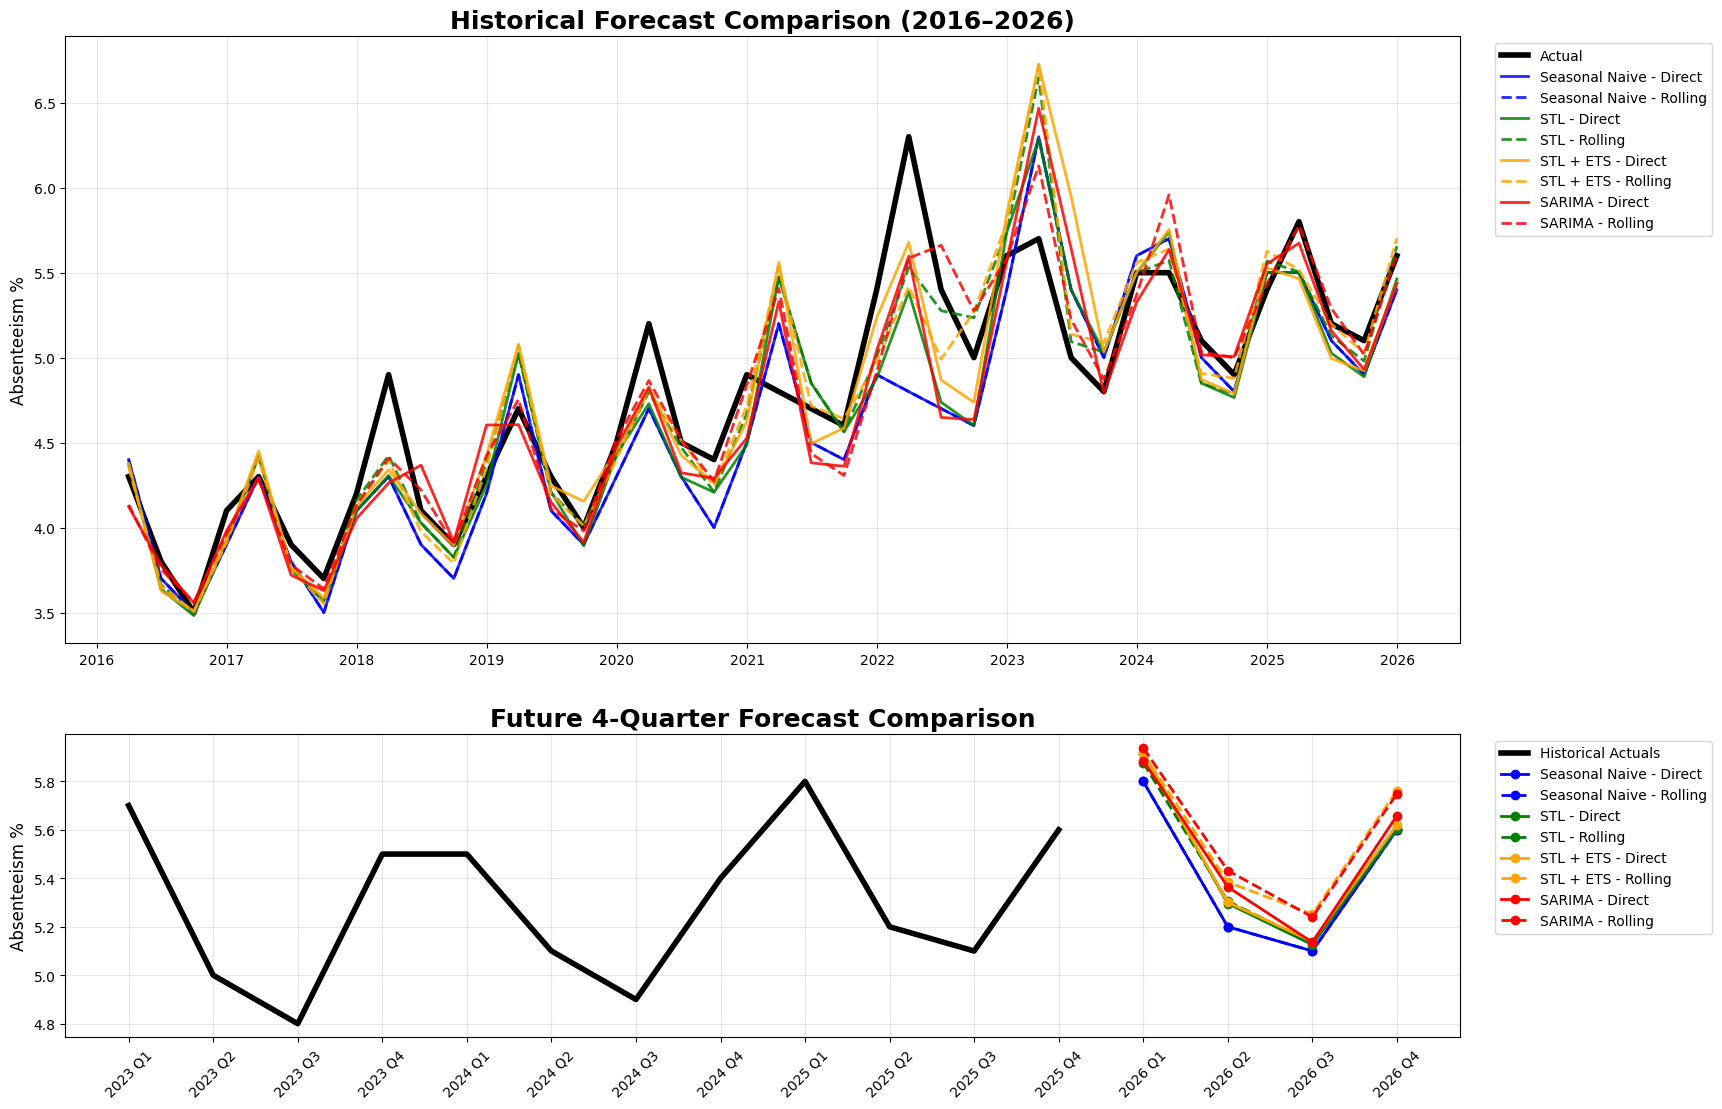

In [48]:
# ============================================================
# COMPREHENSIVE FORECASTING COMPARISON
# DIRECT 4-STEP vs RECURSIVE ROLLING
# ============================================================

# MODELS:
# 1. Seasonal Naive
# 2. STL
# 3. STL + ETS
# 4. SARIMA
#
# STRATEGIES:
# A. Direct 4-Step Forecasting
# B. Recursive Rolling Forecasting
#
# OUTPUTS:
# - Accuracy comparison table
# - Future 4-quarter forecasts
# ============================================================


from statsmodels.tsa.forecasting.stl import STLForecast
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX


# ============================================================
# PARAMETERS
# ============================================================

FORECAST_HORIZON = 4
WINDOW_SIZE = 40


# ============================================================
# STORAGE
# ============================================================

results_all = {}


# ============================================================
# HELPER FUNCTION
# ============================================================

def store_results(name, dates, actuals, forecasts):

    df_results = pd.DataFrame({
        "date": dates,
        "actual": actuals,
        "forecast": forecasts
    })

    metrics = calculate_metrics(
        df_results["actual"],
        df_results["forecast"]
    )

    results_all[name] = {
        "results": df_results,
        "metrics": metrics
    }


# ============================================================
# 1. SEASONAL NAIVE — DIRECT 4-STEP
# ============================================================

dates = []
actuals = []
forecasts = []

for i in range(
    INITIAL_TRAIN_SIZE,
    len(df_ts) - FORECAST_HORIZON + 1
):

    train = df_ts.iloc[:i]
    test = df_ts.iloc[i:i + FORECAST_HORIZON]

    forecast = train.iloc[-4:].values

    dates.extend(test.index)
    actuals.extend(test.values)
    forecasts.extend(forecast)

store_results(
    "Seasonal Naive - Direct",
    dates,
    actuals,
    forecasts
)


# ============================================================
# 2. SEASONAL NAIVE — RECURSIVE ROLLING
# ============================================================

dates = []
actuals = []
forecasts = []

for i in range(
    WINDOW_SIZE,
    len(df_ts)
):

    train = df_ts.iloc[i-WINDOW_SIZE:i]
    test = df_ts.iloc[i]

    forecast = train.iloc[-4]

    dates.append(df_ts.index[i])
    actuals.append(test)
    forecasts.append(forecast)

store_results(
    "Seasonal Naive - Rolling",
    dates,
    actuals,
    forecasts
)


# ============================================================
# 3. STL — DIRECT 4-STEP
# ============================================================

dates = []
actuals = []
forecasts = []

for i in range(
    INITIAL_TRAIN_SIZE,
    len(df_ts) - FORECAST_HORIZON + 1
):

    train = df_ts.iloc[:i]
    test = df_ts.iloc[i:i + FORECAST_HORIZON]

    stl = STL(
        train,
        period=4,
        robust=True
    )

    result = stl.fit()

    seasonal = result.seasonal.iloc[-4:].values
    trend_last = result.trend.iloc[-1]

    forecast = trend_last + seasonal

    dates.extend(test.index)
    actuals.extend(test.values)
    forecasts.extend(forecast)

store_results(
    "STL - Direct",
    dates,
    actuals,
    forecasts
)


# ============================================================
# 4. STL — RECURSIVE ROLLING
# ============================================================

dates = []
actuals = []
forecasts = []

for i in range(
    WINDOW_SIZE,
    len(df_ts)
):

    train = df_ts.iloc[i-WINDOW_SIZE:i]

    stl = STL(
        train,
        period=4,
        robust=True
    )

    result = stl.fit()

    forecast = (
        result.trend.iloc[-1]
        + result.seasonal.iloc[-4]
    )

    dates.append(df_ts.index[i])
    actuals.append(df_ts.iloc[i])
    forecasts.append(forecast)

store_results(
    "STL - Rolling",
    dates,
    actuals,
    forecasts
)


# ============================================================
# 5. STL + ETS — DIRECT 4-STEP
# ============================================================

dates = []
actuals = []
forecasts = []

for i in range(
    INITIAL_TRAIN_SIZE,
    len(df_ts) - FORECAST_HORIZON + 1
):

    train = df_ts.iloc[:i]
    test = df_ts.iloc[i:i + FORECAST_HORIZON]

    model = STLForecast(
        train,
        model=ETSModel,
        period=4,
        robust=True,
        model_kwargs={
            "error": "add",
            "trend": "add",
            "seasonal": None
        }
    )

    fit = model.fit()

    forecast = fit.forecast(
        FORECAST_HORIZON
    )

    dates.extend(test.index)
    actuals.extend(test.values)
    forecasts.extend(forecast.values)

store_results(
    "STL + ETS - Direct",
    dates,
    actuals,
    forecasts
)


# ============================================================
# 6. STL + ETS — RECURSIVE ROLLING
# ============================================================

dates = []
actuals = []
forecasts = []

for i in range(
    WINDOW_SIZE,
    len(df_ts)
):

    train = df_ts.iloc[i-WINDOW_SIZE:i]

    model = STLForecast(
        train,
        model=ETSModel,
        period=4,
        robust=True,
        model_kwargs={
            "error": "add",
            "trend": "add",
            "seasonal": None
        }
    )

    fit = model.fit()

    forecast = fit.forecast(1)

    dates.append(df_ts.index[i])
    actuals.append(df_ts.iloc[i])
    forecasts.append(forecast.iloc[0])

store_results(
    "STL + ETS - Rolling",
    dates,
    actuals,
    forecasts
)


# ============================================================
# 7. SARIMA — DIRECT 4-STEP
# ============================================================

dates = []
actuals = []
forecasts = []

for i in range(
    INITIAL_TRAIN_SIZE,
    len(df_ts) - FORECAST_HORIZON + 1
):

    train = df_ts.iloc[:i]
    test = df_ts.iloc[i:i + FORECAST_HORIZON]

    model = SARIMAX(
        train,
        order=(1,1,1),
        seasonal_order=(1,0,1,4),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fit = model.fit(disp=False)

    forecast = fit.forecast(
        FORECAST_HORIZON
    )

    dates.extend(test.index)
    actuals.extend(test.values)
    forecasts.extend(forecast.values)

store_results(
    "SARIMA - Direct",
    dates,
    actuals,
    forecasts
)


# ============================================================
# 8. SARIMA — RECURSIVE ROLLING
# ============================================================

dates = []
actuals = []
forecasts = []

for i in range(
    WINDOW_SIZE,
    len(df_ts)
):

    train = df_ts.iloc[i-WINDOW_SIZE:i]

    model = SARIMAX(
        train,
        order=(1,1,1),
        seasonal_order=(1,0,1,4),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fit = model.fit(disp=False)

    forecast = fit.forecast(1)

    dates.append(df_ts.index[i])
    actuals.append(df_ts.iloc[i])
    forecasts.append(forecast.iloc[0])

store_results(
    "SARIMA - Rolling",
    dates,
    actuals,
    forecasts
)


# ============================================================
# COMPARISON TABLE
# ============================================================

comparison = []

for model_name, model_data in results_all.items():

    comparison.append({
        "Model": model_name,
        **model_data["metrics"]
    })

comparison_df = pd.DataFrame(
    comparison
)

comparison_df = comparison_df.round(3)

comparison_df = comparison_df.sort_values(
    "RMSE"
).reset_index(drop=True)

print("MODEL PERFORMANCE COMPARISON")

display(comparison_df)


# ============================================================
# FUTURE FORECASTS
# ============================================================

future_dates = pd.date_range(
    start=df_ts.index[-1] + pd.offsets.QuarterEnd(),
    periods=4,
    freq="QE"
)

future_df = pd.DataFrame({
    "date": future_dates
})


# ============================================================
# SEASONAL NAIVE
# ============================================================

future_df["Seasonal Naive - Direct"] = (
    df_ts.iloc[-4:].values
)

future_df["Seasonal Naive - Rolling"] = (
    df_ts.iloc[-4:].values
)


# ============================================================
# STL
# ============================================================

stl_full = STL(
    df_ts,
    period=4,
    robust=True
).fit()

future_df["STL - Direct"] = (
    stl_full.trend.iloc[-1]
    + stl_full.seasonal.iloc[-4:].values
)

rolling_train = df_ts.iloc[-WINDOW_SIZE:]

stl_roll = STL(
    rolling_train,
    period=4,
    robust=True
).fit()

future_df["STL - Rolling"] = (
    stl_roll.trend.iloc[-1]
    + stl_roll.seasonal.iloc[-4:].values
)


# ============================================================
# STL + ETS
# ============================================================

model_direct = STLForecast(
    df_ts,
    model=ETSModel,
    period=4,
    robust=True,
    model_kwargs={
        "error": "add",
        "trend": "add",
        "seasonal": None
    }
)

fit_direct = model_direct.fit()

future_df["STL + ETS - Direct"] = (
    fit_direct.forecast(4).values
)

rolling_train = df_ts.iloc[-WINDOW_SIZE:]

model_roll = STLForecast(
    rolling_train,
    model=ETSModel,
    period=4,
    robust=True,
    model_kwargs={
        "error": "add",
        "trend": "add",
        "seasonal": None
    }
)

fit_roll = model_roll.fit()

future_df["STL + ETS - Rolling"] = (
    fit_roll.forecast(4).values
)


# ============================================================
# SARIMA
# ============================================================

sarima_direct = SARIMAX(
    df_ts,
    order=(1,1,1),
    seasonal_order=(1,0,1,4),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

future_df["SARIMA - Direct"] = (
    sarima_direct.forecast(4).values
)

rolling_train = df_ts.iloc[-WINDOW_SIZE:]

sarima_roll = SARIMAX(
    rolling_train,
    order=(1,1,1),
    seasonal_order=(1,0,1,4),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

future_df["SARIMA - Rolling"] = (
    sarima_roll.forecast(4).values
)


# ============================================================
# ROUND RESULTS
# ============================================================

future_df = future_df.round(3)

print("\nFUTURE 4-QUARTER FORECASTS")

display(future_df)

# ============================================================
# PROFESSIONAL MODEL COMPARISON VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ============================================================
# CLEAN + PREPARE HISTORICAL DATA
# ============================================================

historical_frames = []

for model_name, model_data in results_all.items():

    df_model = model_data["results"].copy()

    # --------------------------------------------------------
    # ENSURE DATETIME
    # --------------------------------------------------------

    df_model["date"] = pd.to_datetime(
        df_model["date"]
    )

    # --------------------------------------------------------
    # SORT CHRONOLOGICALLY
    # --------------------------------------------------------

    df_model = df_model.sort_values(
        "date"
    )

    # --------------------------------------------------------
    # REMOVE DUPLICATES
    # --------------------------------------------------------

    df_model = df_model.drop_duplicates(
        subset="date",
        keep="last"
    )

    # --------------------------------------------------------
    # KEEP ONLY FORECAST COLUMN
    # --------------------------------------------------------

    df_model = df_model.rename(columns={
        "forecast": model_name
    })

    df_model = df_model[
        ["date", model_name]
    ]

    historical_frames.append(df_model)

# ============================================================
# MERGE ALL MODELS
# ============================================================

historical_df = historical_frames[0]

for df_next in historical_frames[1:]:

    historical_df = historical_df.merge(
        df_next,
        on="date",
        how="outer"
    )

# ============================================================
# ADD ACTUAL VALUES
# ============================================================

actual_df = results_all[
    "SARIMA - Direct"
]["results"][["date", "actual"]].copy()

actual_df["date"] = pd.to_datetime(
    actual_df["date"]
)

actual_df = actual_df.drop_duplicates(
    subset="date"
)

historical_df = historical_df.merge(
    actual_df,
    on="date",
    how="left"
)

# ============================================================
# FINAL CLEANING
# ============================================================

historical_df = historical_df.sort_values(
    "date"
)

historical_df = historical_df.set_index(
    "date"
)

# ============================================================
# FILTER 2016–2026
# ============================================================

historical_df = historical_df.loc[
    "2016":"2026"
]

# ============================================================
# FUTURE FORECAST DATAFRAME
# ============================================================

future_forecast_df = future_df.copy()

future_forecast_df["date"] = pd.to_datetime(
    future_forecast_df["date"]
)

future_forecast_df = future_forecast_df.set_index(
    "date"
)

future_forecast_df = future_forecast_df.sort_index()

# ============================================================
# LAST HISTORICAL OBSERVATIONS
# ============================================================

historical_tail = df_ts.loc[
    "2023":
].copy()

historical_tail = pd.DataFrame({
    "actual": historical_tail
})

# ============================================================
# CREATE QUARTER LABELS
# ============================================================

future_labels = [
    f"{d.year} Q{d.quarter}"
    for d in future_forecast_df.index
]

# ============================================================
# CREATE FIGURE
# ============================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(18, 13),
    gridspec_kw={
        "height_ratios": [2, 1]
    }
)

# ============================================================
# TOP PANEL — HISTORICAL PERFORMANCE
# ============================================================

ax1 = axes[0]

# ------------------------------------------------------------
# ACTUAL
# ------------------------------------------------------------

ax1.plot(
    historical_df.index,
    historical_df["actual"],
    color="black",
    linewidth=4,
    label="Actual"
)

# ============================================================
# COLOR MAP
# ============================================================

model_styles = {

    "Seasonal Naive - Direct": {
        "color": "blue",
        "linestyle": "-"
    },

    "Seasonal Naive - Rolling": {
        "color": "blue",
        "linestyle": "--"
    },

    "STL - Direct": {
        "color": "green",
        "linestyle": "-"
    },

    "STL - Rolling": {
        "color": "green",
        "linestyle": "--"
    },

    "STL + ETS - Direct": {
        "color": "orange",
        "linestyle": "-"
    },

    "STL + ETS - Rolling": {
        "color": "orange",
        "linestyle": "--"
    },

    "SARIMA - Direct": {
        "color": "red",
        "linestyle": "-"
    },

    "SARIMA - Rolling": {
        "color": "red",
        "linestyle": "--"
    }
}

# ============================================================
# PLOT MODELS
# ============================================================

for col in model_columns:

    ax1.plot(
        historical_df.index,
        historical_df[col],
        linewidth=2,
        alpha=0.85,
        label=col,
        color=model_styles[col]["color"],
        linestyle=model_styles[col]["linestyle"]
    )

# ------------------------------------------------------------
# FORMATTING
# ------------------------------------------------------------

ax1.set_title(
    "Historical Forecast Comparison (2016–2026)",
    fontsize=18,
    fontweight="bold"
)

ax1.set_ylabel(
    "Absenteeism %",
    fontsize=12
)

ax1.grid(
    True,
    alpha=0.3
)

_ = ax1.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

# ============================================================
# BOTTOM PANEL — FUTURE FORECASTS
# ============================================================

ax2 = axes[1]

# ------------------------------------------------------------
# CREATE QUARTER LABELS
# ------------------------------------------------------------

hist_labels = [
    f"{d.year} Q{d.quarter}"
    for d in historical_tail.index
]

future_labels = [
    f"{d.year} Q{d.quarter}"
    for d in future_forecast_df.index
]

# ------------------------------------------------------------
# PLOT LAST HISTORICAL ACTUALS
# ------------------------------------------------------------

ax2.plot(
    hist_labels,
    historical_tail["actual"].values,
    color="black",
    linewidth=4,
    label="Historical Actuals"
)

# ------------------------------------------------------------
# PLOT FUTURE FORECASTS
# ------------------------------------------------------------

for col in future_forecast_df.columns:

    ax2.plot(
        future_labels,
        future_forecast_df[col].values,
        marker="o",
        linewidth=2,
        label=col,
        color=model_styles[col]["color"],
        linestyle=model_styles[col]["linestyle"]
    )

# ------------------------------------------------------------
# FORMATTING
# ------------------------------------------------------------

ax2.set_title(
    "Future 4-Quarter Forecast Comparison",
    fontsize=18,
    fontweight="bold"
)

ax2.set_ylabel(
    "Absenteeism %",
    fontsize=12
)

ax2.grid(
    True,
    alpha=0.3
)

plt.setp(
    ax2.get_xticklabels(),
    rotation=45
)

_ = ax2.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)